# DeepLOB: FI-2010 Training → LOBSTER Transfer Benchmark

**Goal:** Train DeepLOB fully on FI-2010 (Setup 2), then benchmark transfer to LOBSTER data via:
- **Zero-shot**: evaluate FI-2010-trained model on LOBSTER with no adaptation
- **Few-shot fine-tune**: sweep over [1%, 5%, 10%, 20%, 50%] of LOBSTER training data

This establishes our cross-market transfer baseline before adding synthetic (LOBS5) pre-training.

---
**Datasets:**
- [FI-2010](https://etsin.fairdata.fi/dataset/73eb48d7-4dbc-4a10-a52a-da745b47a649) — 10 days, 5 NASDAQ Nordic stocks, horizon k ∈ {10, 20, 50}
- [LOBSTER](https://lobsterdata.com/) — US equities, NASDAQ, tick-by-tick order book


In [ ]:
!pip install -q huggingface_hub

import os
import random
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from huggingface_hub import hf_hub_download
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.metrics import f1_score, classification_report, confusion_matrix, balanced_accuracy_score

# ── Reproducibility ──────────────────────────────────────────────────────────
GLOBAL_SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(GLOBAL_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
!mkdir -p /content/data
!unzip -q -o /content/drive/MyDrive/colab_data/FI-2010.zip -d /content/data/
!unzip -q -o /content/data/published/BenchmarkDatasets/BenchmarkDatasets.zip -d /content/data/


Mounted at /content/drive/


In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT      = Path('/content/data')
RESULTS_DIR    = Path('./results')
CHECKPOINT_DIR = Path('./checkpoints')
RESULTS_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

DRIVE_ROOT     = Path('/content/drive/MyDrive/colab_data')
DRIVE_CKPT_DIR = DRIVE_ROOT / 'lob_checkpoints'
try:
    DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)
    SAVE_TO_DRIVE = True
except Exception:
    SAVE_TO_DRIVE = False
    print('Drive not available — saving checkpoints locally only.')

# ── Restore checkpoints from Drive on session start ───────────────────────────
if SAVE_TO_DRIVE and DRIVE_CKPT_DIR.exists():
    import shutil
    restored = 0
    for pt in DRIVE_CKPT_DIR.glob('*.pt'):
        dest = CHECKPOINT_DIR / pt.name
        if not dest.exists():
            shutil.copy(pt, dest)
            print(f'Restored {pt.name} from Drive')
            restored += 1
    if restored == 0:
        print('No checkpoints to restore (either already local or Drive is empty)')
else:
    print('Drive not mounted or DRIVE_CKPT_DIR not found — skipping restore')

# ── FI-2010 training config (paper hyperparameters) ──────────────────────────
T          = 100
HORIZONS   = [10, 20, 50]
BATCH_SIZE = 32
LR         = 1e-2
LR_EPS     = 1.0
MAX_EPOCHS = 100
PATIENCE   = 20

# ── Few-shot config ───────────────────────────────────────────────────────────
FEW_SHOT_FRACTIONS = [0.01, 0.05, 0.10, 0.20, 0.50]
FEW_SHOT_MODES     = ['full', 'head_only']
FEW_SHOT_LR        = 1e-4
FEW_SHOT_EPOCHS    = 30
FEW_SHOT_PATIENCE  = 7
N_FEW_SEEDS        = 3

# ── LOBSTER / HuggingFace config ─────────────────────────────────────────────
HF_REPO_ID       = 'totalorganfailure/lobster-data'
LOBSTER_LEVELS   = 10
ALPHA_THRESHOLD  = 1e-5
TRAIN_EVENT_FRAC = 0.7   # temporal split within each stock's single day

# Stocks available at 10 levels
LOBSTER_TICKERS = ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']

# HF filename components
LOBSTER_DATE  = '2012-06-21'
LOBSTER_START = '34200000'
LOBSTER_END   = '57600000'

Restored DeepLOB_k10.pt from Drive
Restored DeepLOB_k20.pt from Drive
Restored DeepLOB_k50.pt from Drive


## 1. FI-2010 Data Loading

Setup 2: first 7 days → train, last 3 days → test. z-score normalisation pre-applied by the dataset authors. Each raw file is (features+labels × events); last 5 rows are the 5-horizon labels.

In [ ]:
def load_fi2010_setup2(
    data_root: Path,
    auction: str       = 'NoAuction',
    normalisation: str = 'Zscore',
    horizon_idx: int   = 0,
    n_train_files: int = 7,
):
    """
    Load FI-2010 in Setup 2.
    horizon_idx: 0->k=10, 1->k=20, 2->k=30, 3->k=50, 4->k=100
    """
    norm_map = {
        'NoAuction': {
            'Zscore': ('1.NoAuction_Zscore', 'NoAuction_Zscore', 'ZScore'),
            'MinMax': ('2.NoAuction_MinMax',  'NoAuction_MinMax', 'MinMax'),
            'DecPre': ('3.NoAuction_DecPre',  'NoAuction_DecPre', 'DecPre'),
        },
    }
    folder_num, split_prefix, fname_norm = norm_map[auction][normalisation]
    base      = data_root / 'BenchmarkDatasets' / auction / folder_num
    train_dir = base / f'{split_prefix}_Training'
    test_dir  = base / f'{split_prefix}_Testing'

    def _load_files(directory, prefix, indices):
        Xs, ys = [], []
        for i in indices:
            fname = directory / f'{prefix}_Dst_{auction}_{fname_norm}_CF_{i}.txt'
            if not fname.exists():
                raise FileNotFoundError(f'Missing: {fname}')
            arr = np.loadtxt(fname)
            X   = arr[:40, :].T.astype(np.float32)
            y   = arr[-(5 - horizon_idx), :].astype(int) - 1
            Xs.append(X); ys.append(y)
        return np.concatenate(Xs, axis=0), np.concatenate(ys, axis=0)

    train_idx = list(range(1, n_train_files + 1))
    test_idx  = list(range(n_train_files + 1, 10))
    X_train, y_train = _load_files(train_dir, 'Train', train_idx)
    X_test,  y_test  = _load_files(test_dir,  'Test',  test_idx)
    return X_train, y_train, X_test, y_test


fi2010 = {}
for h_idx, k_label in zip([0, 1, 3], [10, 20, 50]):
    X_tr, y_tr, X_te, y_te = load_fi2010_setup2(
        DATA_ROOT, auction='NoAuction', normalisation='Zscore', horizon_idx=h_idx
    )
    fi2010[k_label] = (X_tr, y_tr, X_te, y_te)
    print(f'k={k_label}: Train={X_tr.shape}  Test={X_te.shape}  labels={np.bincount(y_tr)}')


k=10: Train=(1017738, 40)  Test=(84109, 40)  labels=[198645 621798 197295]
k=20: Train=(1017738, 40)  Test=(84109, 40)  labels=[255761 509451 252526]
k=50: Train=(1017738, 40)  Test=(84109, 40)  labels=[348647 329267 339824]


## 2. Dataset & DataLoader

Each sample is a sliding window of T=100 consecutive LOB states → shape (T, 40). Label is the mid-price movement class at the end of the window.

In [ ]:
class LOBDataset(Dataset):
    """
    Sliding-window LOB dataset.
    Each sample: X[i : i+T] -> (T, 40), label y[i+T-1]
    """
    def __init__(self, X: np.ndarray, y: np.ndarray, T: int = 100):
        super().__init__()
        assert len(X) == len(y)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.T = T

    def __len__(self):
        return len(self.X) - self.T + 1

    def __getitem__(self, idx):
        return self.X[idx : idx + self.T], self.y[idx + self.T - 1]


def make_loaders(
    X_train, y_train, X_test, y_test,
    fraction: float = 1.0,
    T: int          = 100,
    batch_size: int = 32,
    seed: int       = 42,
):
    """Build train/test DataLoaders. Sub-samples train contiguously to preserve time order."""
    train_full = LOBDataset(X_train, y_train, T)
    test_ds    = LOBDataset(X_test,  y_test,  T)
    n_subset   = max(1, int(len(train_full) * fraction))
    train_ds   = Subset(train_full, list(range(n_subset)))

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=(DEVICE.type == 'cuda')
    )
    test_loader = DataLoader(
        test_ds, batch_size=512, shuffle=False,
        num_workers=2, pin_memory=(DEVICE.type == 'cuda')
    )
    return train_loader, test_loader, n_subset


# Sanity check
_tl, _vl, _ = make_loaders(*fi2010[10], fraction=0.01)
_xb, _yb = next(iter(_tl))
print(f'Batch shapes — X: {_xb.shape}  y: {_yb.shape}')
del _tl, _vl, _xb, _yb


Batch shapes — X: torch.Size([32, 100, 40])  y: torch.Size([32])


## 3. DeepLOB Architecture

Faithful re-implementation of Zhang et al. (2019):
`Conv(1×2 stride) × 2 → Conv(1×10) → Inception@32 → LSTM(64) → Softmax(3)`

Input: **(B, T, 40)** — batch of T-step LOB windows  
Output: **(B, 3)** — logits over {down, stationary, up}

In [ ]:
class InceptionModule(nn.Module):
    """Inception module — Figure 4 of Zhang et al. (2019)."""

    def __init__(self, in_channels: int, n_filters: int = 32):
        super().__init__()
        self.b1_1x1  = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')
        self.b1_3x1  = nn.Conv2d(n_filters,   n_filters, kernel_size=(3, 1), padding='same')
        self.b2_1x1  = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')
        self.b2_5x1  = nn.Conv2d(n_filters,   n_filters, kernel_size=(5, 1), padding='same')
        self.b3_pool = nn.MaxPool2d(kernel_size=(3, 1), stride=1, padding=(1, 0))
        self.b3_1x1  = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')
        self.bn      = nn.BatchNorm2d(n_filters * 3)
        self.act     = nn.LeakyReLU(0.01)

    def forward(self, x):
        b1 = self.act(self.b1_3x1(self.act(self.b1_1x1(x))))
        b2 = self.act(self.b2_5x1(self.act(self.b2_1x1(x))))
        b3 = self.act(self.b3_1x1(self.b3_pool(x)))
        return self.act(self.bn(torch.cat([b1, b2, b3], dim=1)))


class DeepLOB(nn.Module):
    """
    DeepLOB — Zhang et al. (2019).
    Input:  (B, T, 40)
    Output: (B, 3)
    """
    def __init__(self, T: int = 100, n_classes: int = 3):
        super().__init__()
        # Block 1: summarise {price, volume} pairs at each LOB level
        self.conv1a = nn.Conv2d(1,  16, kernel_size=(1, 2), stride=(1, 2))
        self.conv1b = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        self.conv1c = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        # Block 2: bid/ask summarisation -> micro-price features
        self.conv2a = nn.Conv2d(16, 16, kernel_size=(1, 2), stride=(1, 2))
        self.conv2b = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        self.conv2c = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        # Block 3: integrate all 10 levels into one feature per timestep
        self.conv3a     = nn.Conv2d(16, 16, kernel_size=(1, 10))
        self.conv3b     = nn.Conv2d(16, 16, kernel_size=(4, 1), padding=(2, 0))
        self.conv3c     = nn.Conv2d(16, 16, kernel_size=(4, 1), padding=(2, 0))
        self.bn_spatial = nn.BatchNorm2d(16)
        # Inception
        self.inception  = InceptionModule(in_channels=16, n_filters=32)  # -> 96 ch
        # LSTM: (B, 96, T, 1) -> (B, T, 96) -> hidden (B, 64)
        self.lstm       = nn.LSTM(input_size=96, hidden_size=64, batch_first=True)
        self.classifier = nn.Linear(64, n_classes)
        self.act        = nn.LeakyReLU(0.01)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, p in m.named_parameters():
                    if 'weight' in name: nn.init.orthogonal_(p)
                    elif 'bias'  in name: nn.init.zeros_(p)

    def forward(self, x):
        x = x.unsqueeze(1)                        # (B, 1, T, 40)
        x = self.act(self.conv1a(x))
        x = self.act(self.conv1b(x))
        x = self.act(self.conv1c(x))
        x = self.act(self.conv2a(x))
        x = self.act(self.conv2b(x))
        x = self.act(self.conv2c(x))
        x = self.act(self.conv3a(x))
        x = self.act(self.conv3b(x))
        x = self.act(self.bn_spatial(self.conv3c(x)))
        x = self.inception(x)                     # (B, 96, T, 1)
        x = x.squeeze(-1).permute(0, 2, 1)        # (B, T, 96)
        _, (h, _) = self.lstm(x)
        return self.classifier(h.squeeze(0))      # (B, 3)


# Shape & parameter check
_m = DeepLOB(T=T).to(DEVICE)
_d = torch.randn(4, T, 40).to(DEVICE)
print(f'Output shape : {_m(_d).shape}')
print(f'Parameters   : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _d


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


Output shape : torch.Size([4, 3])
Parameters   : 61,171


## 4. Training & Evaluation Utilities

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in loader:
        preds = model(xb.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
    f1      = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    acc     = float(np.mean(np.array(all_preds) == np.array(all_labels)))
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    return f1, acc, bal_acc, all_preds, all_labels


def ckpt_path(horizon: int) -> Path:
    return CHECKPOINT_DIR / f'DeepLOB_k{horizon}.pt'


def train_and_checkpoint(
    train_loader,
    test_loader,
    checkpoint_path: Path,
    max_epochs: int = MAX_EPOCHS,
    patience: int   = PATIENCE,
    lr: float       = LR,
    lr_eps: float   = LR_EPS,
    device          = DEVICE,
    verbose: bool   = True,
):
    """
    Train DeepLOB from scratch with paper hyperparameters.
    Saves best checkpoint. Skips training if checkpoint already exists.
    Returns (best_f1, best bal_acc, model, history).
    """
    if checkpoint_path.exists():
        payload = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model   = DeepLOB(T=T).to(device)
        model.load_state_dict(payload['state_dict'])
        model.eval()
        print(f'  Loaded existing checkpoint -> F1={payload["best_f1"]:.4f}')
        return payload['best_f1'], payload.get('best_bal_acc', float('nan')), model, payload['history']

    model     = DeepLOB(T=T).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, eps=lr_eps)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
    )
    criterion = nn.CrossEntropyLoss()

    best_f1, best_bal_acc, best_state, no_improve = 0.0, 0.0, None, 0
    history = []

    for epoch in range(1, max_epochs + 1):
        loss         = train_epoch(model, train_loader, optimizer, criterion, device)
        f1, acc, bal_acc, _, _ = evaluate(model, test_loader, device)
        scheduler.step(bal_acc)

        if bal_acc > best_bal_acc:
            best_bal_acc = bal_acc
            no_improve   = 0
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        history.append({'epoch': epoch, 'loss': loss, 'f1': f1, 'acc': acc, 'bal_acc': bal_acc})
        if verbose and epoch % 10 == 0:
            print(f'    Epoch {epoch:3d} | loss={loss:.4f} | f1={f1:.4f} | bal_acc={bal_acc:.4f} | best={best_bal_acc:.4f}')
        if no_improve >= patience:
            if verbose: print(f'    Early stop @ epoch {epoch}')
            break

    payload = {'state_dict': best_state, 'best_f1': best_f1, 'best_bal_acc': best_bal_acc, 'history': history}
    torch.save(payload, checkpoint_path)
    if SAVE_TO_DRIVE:
        torch.save(payload, DRIVE_CKPT_DIR / checkpoint_path.name)

    model.load_state_dict(best_state)
    model.eval()
    return best_f1, best_bal_acc, model, history


## 5. Full FI-2010 Training

Train DeepLOB on 100% of FI-2010 Setup 2 for each horizon using the paper's exact hyperparameters (Adam lr=0.01, eps=1, batch=32, max_epochs=100, patience=20). Checkpoints are saved so this section can be skipped on re-runs.

Runtime: ~15–25 min per horizon on a T4 GPU.

In [ ]:
fi2010_f1s    = {}   # horizon -> best_f1
fi2010_bal_accs = {}
fi2010_models = {}   # horizon -> trained model

for k in HORIZONS:
    X_tr, y_tr, X_te, y_te = fi2010[k]
    train_ld, test_ld, _   = make_loaders(
        X_tr, y_tr, X_te, y_te,
        fraction=1.0, T=T, batch_size=BATCH_SIZE
    )
    print(f'\n=== k={k} | train={len(train_ld.dataset):,} | test={len(test_ld.dataset):,} ===')
    set_seed(GLOBAL_SEED)

    best_f1, best_bal_acc, model, history = train_and_checkpoint(
        train_ld, test_ld,
        checkpoint_path=ckpt_path(k),
        max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=LR, lr_eps=LR_EPS,
        device=DEVICE, verbose=True,
    )
    fi2010_f1s[k]       = best_f1
    fi2010_bal_accs[k]  = best_bal_acc
    fi2010_models[k]    = model

print('\n=== FI-2010 Training Summary ===')
for k in HORIZONS:
    print(f'  k={k:3d}  F1={fi2010_f1s[k]:.4f}  Bal.Acc={fi2010_bal_accs[k]:.4f}')



=== k=10 | train=1,017,639 | test=84,010 ===
  Loaded existing checkpoint -> F1=0.0000

=== k=20 | train=1,017,639 | test=84,010 ===
  Loaded existing checkpoint -> F1=0.0000

=== k=50 | train=1,017,639 | test=84,010 ===
  Loaded existing checkpoint -> F1=0.0000

=== FI-2010 Training Summary ===
  k= 10  F1=0.0000  Bal.Acc=0.6779
  k= 20  F1=0.0000  Bal.Acc=0.6050
  k= 50  F1=0.0000  Bal.Acc=0.7163


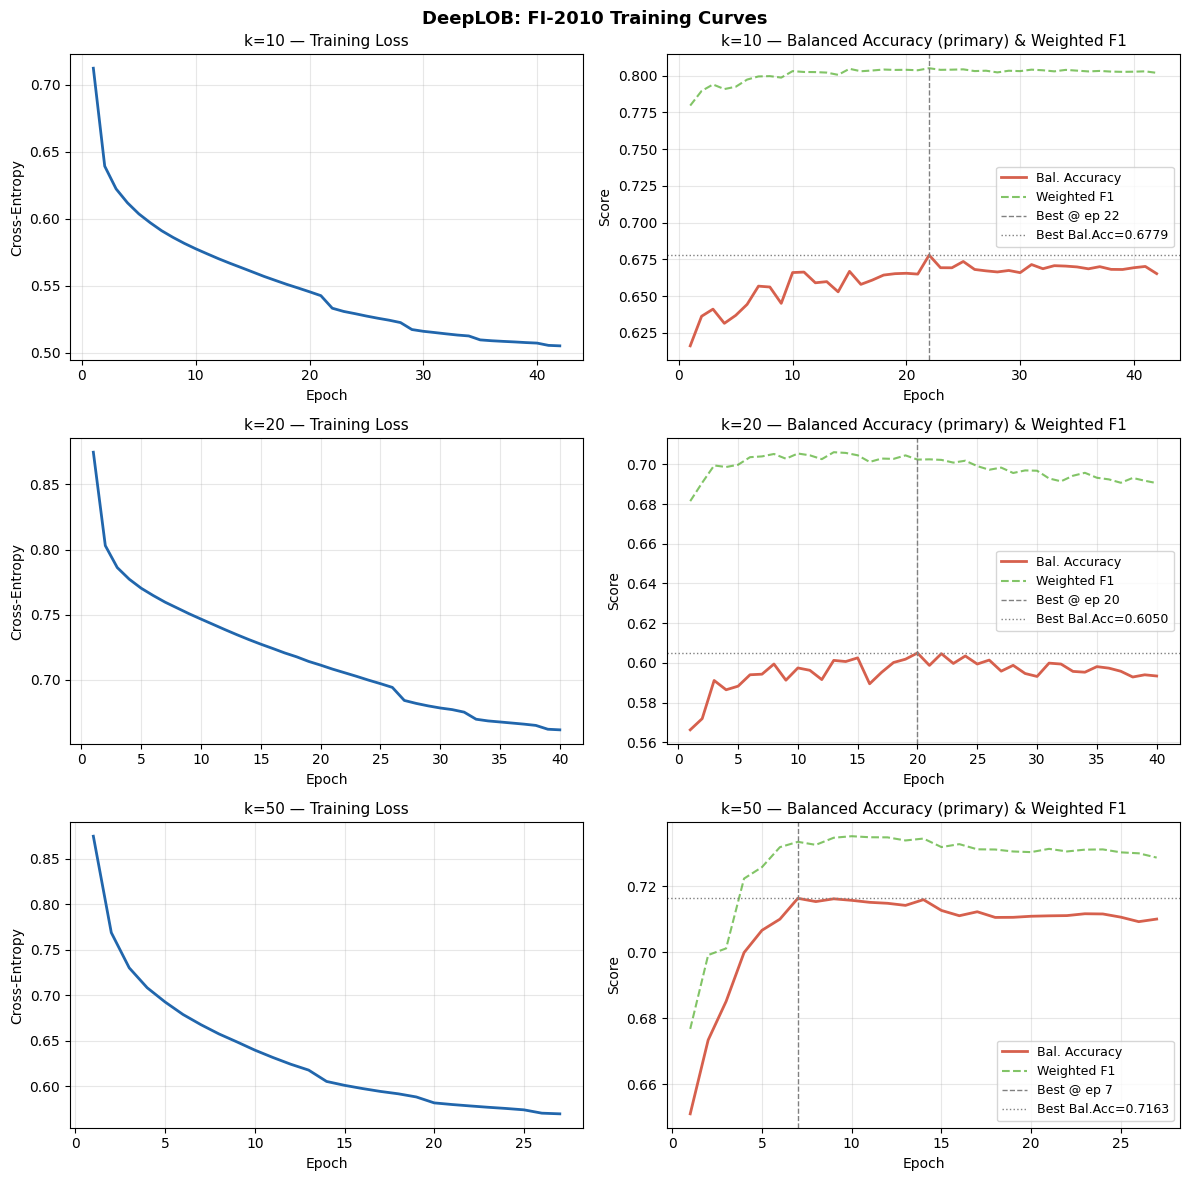

In [ ]:
fig, axes = plt.subplots(len(HORIZONS), 2, figsize=(12, 4 * len(HORIZONS)))

for row, k in enumerate(HORIZONS):
    cp       = torch.load(ckpt_path(k), map_location=DEVICE, weights_only=False)
    history  = cp['history']
    epochs   = [h['epoch']   for h in history]
    losses   = [h['loss']    for h in history]
    bal_accs = [h['bal_acc'] for h in history]
    f1s      = [h['f1']      for h in history]

    ax_loss, ax_bal = axes[row]

    ax_loss.plot(epochs, losses, color='#2166AC', lw=2)
    ax_loss.set_title(f'k={k} — Training Loss', fontsize=11)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Cross-Entropy')
    ax_loss.grid(alpha=0.3)

    best_ep = epochs[int(np.argmax(bal_accs))]
    ax_bal.plot(epochs, bal_accs, color='#D6604D', lw=2, label='Bal. Accuracy')
    ax_bal.plot(epochs, f1s,      color='#4DAC26', lw=1.5, ls='--', alpha=0.7, label='Weighted F1')
    ax_bal.axvline(best_ep, color='grey', ls='--', lw=1,
                   label=f'Best @ ep {best_ep}')
    ax_bal.axhline(max(bal_accs), color='grey', ls=':', lw=1,
                   label=f'Best Bal.Acc={max(bal_accs):.4f}')
    ax_bal.set_title(f'k={k} — Balanced Accuracy (primary) & Weighted F1', fontsize=11)
    ax_bal.set_xlabel('Epoch'); ax_bal.set_ylabel('Score')
    ax_bal.legend(fontsize=9); ax_bal.grid(alpha=0.3)

fig.suptitle('DeepLOB: FI-2010 Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fi2010_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# 5.1 Quick Eval On FI-2010

## 6. LOBSTER Data Loading

LOBSTER produces per-stock, per-day files: `{STOCK}_{DATE}_*_orderbook_10.csv`.  
Each row is one LOB update with columns `[AskP1, AskV1, BidP1, BidV1, ..., AskP10, AskV10, BidP10, BidV10]` — the same {p_a, v_a, p_b, v_b}×10 layout as FI-2010, so the model architecture is unchanged.

**Normalisation:** per-day z-score (no future leakage).  
**Prices:** integer ticks ÷ 10,000 → dollars before normalising.  
**Labels:** Equation 4 from Zhang et al. (2019) — smoothed mid-price change with threshold α.  
**Split:** temporal by day — first 70% of calendar days → train, last 30% → test.

In [ ]:
def hf_orderbook_path(ticker: str) -> str:
    folder = f'LOBSTER_SampleFile_{ticker}_{LOBSTER_DATE}_{LOBSTER_LEVELS}'
    fname  = f'{ticker}_{LOBSTER_DATE}_{LOBSTER_START}_{LOBSTER_END}_orderbook_{LOBSTER_LEVELS}.csv'
    return f'{folder}/{fname}'


raw_paths = {}
for ticker in LOBSTER_TICKERS:
    local_path = hf_hub_download(
        repo_id   = HF_REPO_ID,
        filename  = hf_orderbook_path(ticker),
        repo_type = 'dataset',
    )
    raw_paths[ticker] = local_path
    print(f'Downloaded {ticker}: {local_path}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


LOBSTER_SampleFile_AAPL_2012-06-21_10/AA(…):   0%|          | 0.00/93.5M [00:00<?, ?B/s]

Downloaded AAPL: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv


LOBSTER_SampleFile_AMZN_2012-06-21_10/AM(…):   0%|          | 0.00/63.2M [00:00<?, ?B/s]

Downloaded AMZN: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_AMZN_2012-06-21_10/AMZN_2012-06-21_34200000_57600000_orderbook_10.csv


...

Downloaded GOOG: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_GOOG_2012-06-21_10/GOOG_2012-06-21_34200000_57600000_orderbook_10.csv


LOBSTER_SampleFile_INTC_2012-06-21_10/IN(…):   0%|          | 0.00/158M [00:00<?, ?B/s]

Downloaded INTC: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_INTC_2012-06-21_10/INTC_2012-06-21_34200000_57600000_orderbook_10.csv


LOBSTER_SampleFile_MSFT_2012-06-21_10/MS(…):   0%|          | 0.00/170M [00:00<?, ?B/s]

Downloaded MSFT: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_MSFT_2012-06-21_10/MSFT_2012-06-21_34200000_57600000_orderbook_10.csv


In [ ]:
from sklearn.model_selection import train_test_split

def _zscore(arr):
    return (arr - arr.mean(0, keepdims=True)) / (arr.std(0, keepdims=True) + 1e-8)


def _label_midprice(arr, k, alpha):
    mid    = (arr[:, 0] + arr[:, 2]) / 2.0
    labels = np.ones(len(arr), dtype=np.int64)
    for t in range(k, len(arr) - k):
        m_minus = mid[t - k : t].mean()
        m_plus  = mid[t : t + k].mean()
        if m_minus < 1e-12: continue
        lt = (m_plus - m_minus) / m_minus
        if   lt >  alpha: labels[t] = 2
        elif lt < -alpha: labels[t] = 0
    return labels


def load_lobster_dataset(raw_paths, horizon=10, alpha=ALPHA_THRESHOLD,
                         train_frac=TRAIN_EVENT_FRAC, split_seed=GLOBAL_SEED):
    """
    For each ticker: load -> tick-to-dollar -> per-stock z-score -> label ->
    permutation split (train_frac for train, rest for test) for that day.
    Concatenates all tickers.
    """
    X_trains, y_trains, X_tests, y_tests = [], [], [], []

    for ticker, path in raw_paths.items():
        arr           = np.loadtxt(path, delimiter=',', dtype=np.float32)
        arr[:, 0::2] /= 10_000.0                    # tick -> dollar
        arr           = _zscore(arr)
        labels        = _label_midprice(arr, k=horizon, alpha=alpha)

        # Use train_test_split for a shuffled split
        X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(
            arr, labels, train_size=train_frac, random_state=split_seed, shuffle=True,
            stratify=labels if sum(np.bincount(labels)) > 0 else None # Stratify if labels exist
        )

        X_trains.append(X_tr_t);  y_trains.append(y_tr_t)
        X_tests.append(X_te_t);   y_tests.append(y_te_t)

        print(f'  {ticker}: {len(arr):,} events | '
              f'train={len(X_tr_t):,} test={len(X_te_t):,} | '
              f'labels={np.bincount(labels, minlength=3)}')

    X_train, y_train = np.concatenate(X_trains), np.concatenate(y_trains)
    X_test,  y_test  = np.concatenate(X_tests),  np.concatenate(y_tests)
    print(f'\nCombined | Train: {X_train.shape} | Test: {X_test.shape}')
    return X_train, y_train, X_test, y_test


lobster = {}
for k in HORIZONS:
    print(f'\n--- Horizon k={k} ---')
    lobster[k] = load_lobster_dataset(raw_paths, horizon=k)



--- Horizon k=10 ---
  AAPL: 400,391 events | train=280,273 test=120,118 | labels=[129505 144319 126567]
  AMZN: 269,748 events | train=188,823 test=80,925 | labels=[ 59580 154348  55820]
  GOOG: 147,916 events | train=103,541 test=44,375 | labels=[30756 90202 26958]
  INTC: 624,040 events | train=436,828 test=187,212 | labels=[ 16282 592064  15694]
  MSFT: 668,765 events | train=468,135 test=200,630 | labels=[ 22646 625941  20178]

Combined | Train: (1477600, 40) | Test: (633260, 40)

--- Horizon k=20 ---
  AAPL: 400,391 events | train=280,273 test=120,118 | labels=[146542 113824 140025]
  AMZN: 269,748 events | train=188,823 test=80,925 | labels=[ 73439 127860  68449]
  GOOG: 147,916 events | train=103,541 test=44,375 | labels=[34770 82841 30305]
  INTC: 624,040 events | train=436,828 test=187,212 | labels=[ 29835 565357  28848]
  MSFT: 668,765 events | train=468,135 test=200,630 | labels=[ 42633 588474  37658]

Combined | Train: (1477600, 40) | Test: (633260, 40)

--- Horizon k=50 

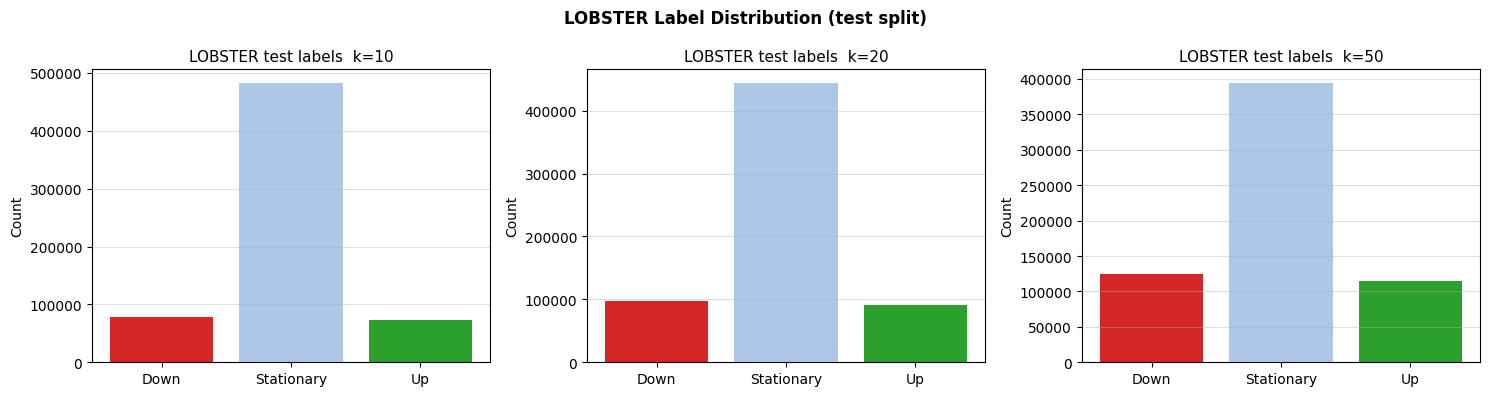

In [ ]:
if lobster:
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 4))
    if len(HORIZONS) == 1: axes = [axes]
    label_names = ['Down', 'Stationary', 'Up']
    colors      = ['#d62728', '#aec7e8', '#2ca02c']
    for ax, k in zip(axes, HORIZONS):
        counts = np.bincount(lobster[k][3], minlength=3)  # y_test
        ax.bar(label_names, counts, color=colors)
        ax.set_title(f'LOBSTER test labels  k={k}', fontsize=11)
        ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.4)
    plt.suptitle('LOBSTER Label Distribution (test split)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 7. Zero-Shot Transfer Benchmark

Load each FI-2010 checkpoint and evaluate directly on LOBSTER — **no adaptation whatsoever**. This is the cross-market transfer floor before any fine-tuning or synthetic pre-training.

In [ ]:
zeroshot_results = []

if not lobster:
    print('LOBSTER not loaded — skipping zero-shot eval.')
else:
    for k in HORIZONS:
        _, _, X_te, y_te = lobster[k]
        test_ds = LOBDataset(X_te, y_te, T)
        test_ld = DataLoader(test_ds, batch_size=512, shuffle=False,
                             num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

        cp = ckpt_path(k)
        if not cp.exists():
            print(f'  Missing checkpoint for k={k} — run Section 5 first.')
            continue

        payload = torch.load(cp, map_location=DEVICE, weights_only=False)
        model   = DeepLOB(T=T).to(DEVICE)
        model.load_state_dict(payload['state_dict'])

        f1, acc, bal_acc, all_preds, all_labels = evaluate(model, test_ld, DEVICE)
        src_f1 = fi2010_f1s.get(k, payload['best_f1'])

        print(f'\n=== Zero-Shot | k={k} ===')
        src_f1      = fi2010_f1s.get(k, payload['best_f1'])
        src_bal_acc = fi2010_bal_accs.get(k, payload.get('best_bal_acc', float('nan')))

        print(f'  FI-2010 F1       : {src_f1:.4f}    FI-2010 Bal.Acc  : {src_bal_acc:.4f}')
        print(f'  LOBSTER F1       : {f1:.4f}    (gap: {src_f1 - f1:+.4f})')
        print(f'  LOBSTER Bal.Acc  : {bal_acc:.4f}    (gap: {src_bal_acc - bal_acc:+.4f})')
        print(classification_report(all_labels, all_preds,
                                    target_names=['Down', 'Stationary', 'Up']))

        zeroshot_results.append({
            'horizon':              k,
            'fi2010_f1':            src_f1,
            'fi2010_bal_acc':       src_bal_acc,
            'lobster_zeroshot_f1':  f1,
            'lobster_zeroshot_acc': acc,
            'transfer_gap_f1':         src_f1 - f1,
            'transfer_gap_bal_acc': src_bal_acc - bal_acc,
            'all_preds':            all_preds,
            'all_labels':           all_labels,
            'lobster_zeroshot_bal_acc': bal_acc,
        })

zs_df = pd.DataFrame([{k: v for k, v in r.items()
                        if k not in ('all_preds', 'all_labels')}
                       for r in zeroshot_results])
if not zs_df.empty:
    zs_df.to_csv(RESULTS_DIR / 'zeroshot_transfer.csv', index=False)
    print('\n=== Zero-Shot Summary ===')
    print(zs_df.to_string(index=False))



=== Zero-Shot | k=10 ===
  FI-2010 F1       : 0.0000    FI-2010 Bal.Acc  : 0.6779
  LOBSTER F1       : 0.2280    (gap: -0.2280)
  LOBSTER Bal.Acc  : 0.3019    (gap: +0.3760)
              precision    recall  f1-score   support

        Down       0.12      0.41      0.18     77604
  Stationary       0.66      0.15      0.25    482027
          Up       0.10      0.34      0.15     73530

    accuracy                           0.21    633161
   macro avg       0.29      0.30      0.19    633161
weighted avg       0.53      0.21      0.23    633161


=== Zero-Shot | k=20 ===
  FI-2010 F1       : 0.0000    FI-2010 Bal.Acc  : 0.6050
  LOBSTER F1       : 0.1409    (gap: -0.1409)
  LOBSTER Bal.Acc  : 0.3056    (gap: +0.2994)
              precision    recall  f1-score   support

        Down       0.15      0.43      0.23     98140
  Stationary       0.51      0.06      0.11    443474
          Up       0.13      0.43      0.20     91547

    accuracy                           0.17    6331

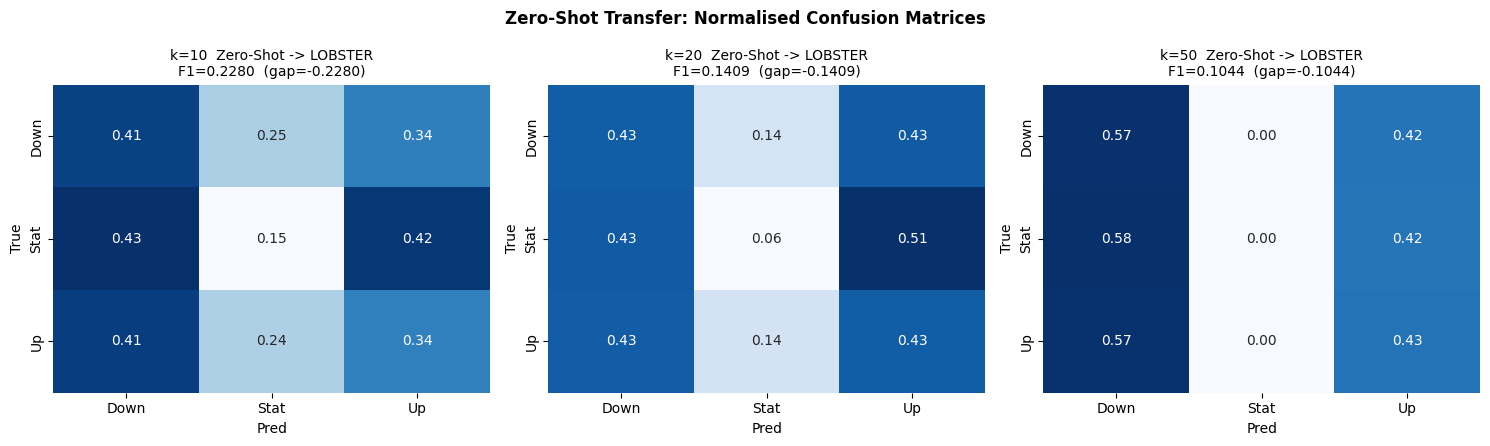

In [ ]:
if zeroshot_results:
    fig, axes = plt.subplots(1, len(zeroshot_results),
                             figsize=(5 * len(zeroshot_results), 4.5))
    if len(zeroshot_results) == 1: axes = [axes]

    for ax, r in zip(axes, zeroshot_results):
        cm = confusion_matrix(r['all_labels'], r['all_preds'], normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', ax=ax, cmap='Blues',
                    xticklabels=['Down', 'Stat', 'Up'],
                    yticklabels=['Down', 'Stat', 'Up'], cbar=False)
        ax.set_title(
            f'k={r["horizon"]}  Zero-Shot -> LOBSTER\n',
            fontsize=10
        )
        ax.set_ylabel('True'); ax.set_xlabel('Pred')

    plt.suptitle('Zero-Shot Transfer: Normalised Confusion Matrices',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'zeroshot_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Few-Shot Fine-Tuning on LOBSTER

Starting from the FI-2010 checkpoint, fine-tune on fractions **[1%, 5%, 10%, 20%, 50%]** of LOBSTER training data. Two modes:

- **Full fine-tune** — all weights updated (LR = 1e-4)  
- **Head-only** — Conv+Inception backbone frozen; only LSTM + classifier updated  

Each (fraction, mode) is run over 3 seeds for error bars. Zero-shot result serves as the 0% anchor.

In [ ]:
def finetune_from_checkpoint(
    checkpoint_path: Path,
    train_loader,
    test_loader,
    mode: str       = 'full',
    max_epochs: int = FEW_SHOT_EPOCHS,
    patience: int   = FEW_SHOT_PATIENCE,
    lr: float       = FEW_SHOT_LR,
    device          = DEVICE,
) -> tuple:
    """
    Load FI-2010 checkpoint, fine-tune on LOBSTER.
    mode='full'      -> all weights updated
    mode='head_only' -> Conv+Inception frozen; LSTM + classifier updated
    Returns (best_f1, history).
    """
    payload = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model   = DeepLOB(T=T).to(device)
    model.load_state_dict(payload['state_dict'])
    model.train()

    if mode == 'head_only':
        for name, param in model.named_parameters():
            if not any(key in name for key in ('lstm', 'classifier')):
                param.requires_grad = False

    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=lr, eps=1e-8)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-7
    )
    criterion = nn.CrossEntropyLoss()

    best_f1, best_bal_acc, best_state, no_improve = 0.0, 0.0, None, 0
    history = []

    for epoch in range(1, max_epochs + 1):
        loss          = train_epoch(model, train_loader, optimizer, criterion, device)
        f1, acc, bal_acc, _, _ = evaluate(model, test_loader, device)
        scheduler.step(bal_acc)


        if bal_acc > best_bal_acc:
          best_bal_acc = bal_acc
          best_f1      = f1      # track F1 at best bal_acc point for reporting
          no_improve   = 0
          best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        history.append({'epoch': epoch, 'loss': loss, 'f1': f1})
        if no_improve >= patience:
            break

    return best_f1, best_bal_acc, history


In [16]:
# Runtime: ~1-2 min per (frac, mode, seed) on T4 -> ~30-60 min total.

fewshot_results = []

if not lobster:
    print('LOBSTER not loaded — skipping few-shot sweep.')
else:
    for k in HORIZONS:
        X_tr, y_tr, X_te, y_te = lobster[k]
        test_ds = LOBDataset(X_te, y_te, T)
        test_ld = DataLoader(test_ds, batch_size=512, shuffle=False,
                             num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

        cp = ckpt_path(k)
        if not cp.exists():
            print(f'Missing checkpoint for k={k} — run Section 5 first.')
            continue

        print(f'\n=== Few-Shot | Horizon k={k} ===')

        for mode in FEW_SHOT_MODES:
            for frac in FEW_SHOT_FRACTIONS:
                f1s_seeds = []
                bal_acc_seeds = []
                for seed in range(N_FEW_SEEDS):
                    set_seed(seed)
                    train_ld, _, n_tr = make_loaders(
                        X_tr, y_tr, X_te, y_te,
                        fraction=frac, T=T,
                        batch_size=BATCH_SIZE, seed=seed
                    )
                    best_f1, best_bal_acc, _ = finetune_from_checkpoint(
                        cp, train_ld, test_ld,
                        mode=mode,
                        max_epochs=FEW_SHOT_EPOCHS,
                        patience=FEW_SHOT_PATIENCE,
                        lr=FEW_SHOT_LR,
                        device=DEVICE,
                    )
                    f1s_seeds.append(best_f1)
                    bal_acc_seeds.append(best_bal_acc)
                    fewshot_results.append({
                        'horizon':  k,
                        'mode':     mode,
                        'fraction': frac,
                        'n_train':  n_tr,
                        'seed':     seed,
                        'f1':       best_f1,
                        'bal_acc': best_bal_acc,
                    })

                print(
                    f'  mode={mode:9s} | frac={frac:.0%} ({n_tr:6,} samples) | '
                    f'F1={np.mean(f1s_seeds):.4f} +/- {np.std(f1s_seeds):.4f} | '
                    f'Bal.Acc={np.mean(bal_acc_seeds):.4f} +/- {np.std(bal_acc_seeds):.4f}'
                )

fs_df = pd.DataFrame(fewshot_results)
if not fs_df.empty:
    fs_df.to_csv(RESULTS_DIR / 'fewshot_transfer.csv', index=False)
    if SAVE_TO_DRIVE:
        fs_df.to_csv(DRIVE_ROOT / 'fewshot_transfer.csv', index=False)
    print('\nSaved fewshot_transfer.csv')



=== Few-Shot | Horizon k=10 ===
  mode=full      | frac=1% (14,775 samples) | F1=0.6843 +/- 0.0078 | Bal.Acc=0.5258 +/- 0.0004
  mode=full      | frac=5% (73,875 samples) | F1=0.6484 +/- 0.0087 | Bal.Acc=0.5456 +/- 0.0014
  mode=full      | frac=10% (147,750 samples) | F1=0.6307 +/- 0.0012 | Bal.Acc=0.5537 +/- 0.0014
  mode=full      | frac=20% (295,500 samples) | F1=0.6485 +/- 0.0138 | Bal.Acc=0.5619 +/- 0.0021
  mode=full      | frac=50% (738,750 samples) | F1=0.8480 +/- 0.0011 | Bal.Acc=0.6775 +/- 0.0050
  mode=head_only | frac=1% (14,775 samples) | F1=0.6296 +/- 0.0099 | Bal.Acc=0.4631 +/- 0.0029
  mode=head_only | frac=5% (73,875 samples) | F1=0.6544 +/- 0.0069 | Bal.Acc=0.4847 +/- 0.0006
  mode=head_only | frac=10% (147,750 samples) | F1=0.6609 +/- 0.0021 | Bal.Acc=0.4896 +/- 0.0009
  mode=head_only | frac=20% (295,500 samples) | F1=0.6662 +/- 0.0058 | Bal.Acc=0.4982 +/- 0.0008
  mode=head_only | frac=50% (738,750 samples) | F1=0.7703 +/- 0.0047 | Bal.Acc=0.5519 +/- 0.0017

=== 

KeyboardInterrupt: 

## 9. Results: Transfer Gap Visualisation

In [ ]:
if not fs_df.empty and zeroshot_results:

    fs_summary = (
        fs_df.groupby(['horizon', 'mode', 'fraction'])[['f1', 'bal_acc']]
        .agg(['mean', 'std']).reset_index()
    )
    fs_summary.columns = ['horizon', 'mode', 'fraction',
                       'f1_mean', 'f1_std', 'bal_acc_mean', 'bal_acc_std']
    fs_summary[['f1_std', 'bal_acc_std']] = fs_summary[['f1_std', 'bal_acc_std']].fillna(0)

    MODE_STYLES = {
        'full':      {'ls': '-',  'color': '#2166AC', 'label': 'Full fine-tune'},
        'head_only': {'ls': '--', 'color': '#D6604D', 'label': 'Head-only fine-tune'},
    }

    fig, axes = plt.subplots(1, len(HORIZONS),
                             figsize=(6 * len(HORIZONS), 5), sharey=False)
    if len(HORIZONS) == 1: axes = [axes]

    for ax, k in zip(axes, HORIZONS):
        zs_row = next((r for r in zeroshot_results if r['horizon'] == k), None)
        if zs_row:
            zs_bal_acc = zs_row['lobster_zeroshot_bal_acc']
            src_bal_acc = zs_row['fi2010_bal_acc']
            ax.axhline(zs_bal_acc, color='grey', ls=':', lw=1.8,
                label=f'Zero-shot bal.acc ({zs_bal_acc:.3f})')
            ax.axhline(src_bal_acc, color='black', ls='--', lw=1.2, alpha=0.5,
                       label=f'FI-2010 source ({src_f1:.3f})')

        sub = fs_summary[fs_summary['horizon'] == k]
        for mode, mstyle in MODE_STYLES.items():
            m_sub = sub[sub['mode'] == mode].sort_values('fraction')
            if m_sub.empty: continue
            pcts = m_sub['fraction'] * 100
            ax.plot(pcts, m_sub['bal_acc_mean'],
                    ls=mstyle['ls'], color=mstyle['color'],
                    lw=2, marker='o', ms=7, label=mstyle['label'])
            ax.fill_between(pcts,
                            m_sub['bal_acc_mean'] - m_sub['bal_acc_std'],
                            m_sub['bal_acc_mean'] + m_sub['bal_acc_std'],
                            alpha=0.12, color=mstyle['color'])

        ax.set_xscale('log')
        ax.set_xlabel('LOBSTER fine-tuning data (%)', fontsize=11)
        ax.set_ylabel('Balanced Accuracy (LOBSTER test)', fontsize=11)
        ax.set_title(f'Horizon k={k}', fontsize=12, fontweight='bold')
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        ax.xaxis.set_major_locator(mtick.FixedLocator([1, 5, 10, 20, 50]))
        ax.tick_params(axis='x', labelsize=9)
        ax.legend(fontsize=9)
        ax.grid(True, which='both', alpha=0.3)

    fig.suptitle(
        'DeepLOB Transfer: FI-2010 -> LOBSTER\n'
        'Few-shot fine-tuning vs. zero-shot baseline',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'transfer_fewshot.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
print('=' * 72)
print('TRANSFER SUMMARY: DeepLOB  FI-2010 -> LOBSTER')
print('=' * 72)

rows = []
for k in HORIZONS:
    src    = fi2010_f1s.get(k, float('nan'))
    zs_row = next((r for r in zeroshot_results if r['horizon'] == k), None)
    zs     = zs_row['lobster_zeroshot_f1'] if zs_row else float('nan')
    gap    = src - zs if not (np.isnan(src) or np.isnan(zs)) else float('nan')

    for mode in FEW_SHOT_MODES:
        for frac in FEW_SHOT_FRACTIONS:
            sub = fs_df[
                (fs_df['horizon']  == k) &
                (fs_df['mode']     == mode) &
                (np.isclose(fs_df['fraction'], frac))
            ] if not fs_df.empty else pd.DataFrame()
            ft = sub['f1'].mean() if not sub.empty else float('nan')
            rows.append({
                'k':             k,
                'mode':          mode,
                'frac':          f'{frac:.0%}',
                'FI-2010 F1':    f'{src:.4f}' if not np.isnan(src) else '—',
                'Zero-Shot F1':  f'{zs:.4f}'  if not np.isnan(zs)  else '—',
                'Src->ZS gap':   f'{gap:+.4f}'if not np.isnan(gap) else '—',
                'Fine-Tune F1':  f'{ft:.4f}'  if not np.isnan(ft)  else '—',
                'FT gain vs ZS': f'{ft-zs:+.4f}'
                                 if not (np.isnan(ft) or np.isnan(zs)) else '—',
            })

results_table = pd.DataFrame(rows)
print(results_table.to_string(index=False))
results_table.to_csv(RESULTS_DIR / 'transfer_summary.csv', index=False)

print()
print('Key question: how many LOBSTER samples does it take to recover the transfer gap?')
print('This gap is what LOBS5 synthetic pre-training should compress.')
print('=' * 72)
